# Multi-Output XGBoost Model Tuning

Multi-output regression for `total_distance`, `acc_total`, `vel_total` using `MultiOutputRegressor` + XGBoost.  
Hyperparameter tuning via `RandomizedSearchCV` (n_iter=50, 5-fold CV, scoring = mean R² across targets).  
Feature set comparison: base features vs base + position dummies.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, make_scorer
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_parquet("/Users/user/Desktop/Master/REAL-MADRID-INTERNSHIP-GROUP-A/data/processed/model_data.parquet")

targets = ['total_distance', 'acc_total', 'vel_total']

feature_set_1 = [
    'height', 'weight', 'age', 'has_G', 'has_TAC', 'has_BP', 'has_TEC',
    'has_MATCH', 'n_session_types', 'days_since_start',
    'days_since_last_activity', 'days_since_last_match'
]

feature_set_2 = feature_set_1 + [
    'pos_central_back', 'pos_central_midfielder', 'pos_forward',
    'pos_full_back', 'pos_winger'
]

all_cols = feature_set_2 + targets + ['player_id']
df_clean = df[all_cols].dropna()
print(f"Dataset shape after dropna: {df_clean.shape}")
print(f"Feature set 1: {len(feature_set_1)} features (no position)")
print(f"Feature set 2: {len(feature_set_2)} features (with position)")

Dataset shape after dropna: (2103, 21)
Feature set 1: 12 features (no position)
Feature set 2: 17 features (with position)


## 1. Hyperparameter Tuning with RandomizedSearchCV

Using feature set 2 (with position) for tuning. The scoring function is the mean R² across the three targets.

In [3]:
X_tune = df_clean[feature_set_2].values
Y_tune = df_clean[targets].values

scaler_tune = MinMaxScaler()
X_tune_scaled = scaler_tune.fit_transform(X_tune)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'estimator__max_depth': [3, 5, 7, 9, 11],
    'estimator__learning_rate': [0.001, 0.01, 0.05, 0.1, 0.15],
    'estimator__n_estimators': [50, 100, 150, 200, 300, 400],
    'estimator__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'estimator__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'estimator__reg_alpha': [0.0, 0.1, 0.5, 1.0, 2.0],
    'estimator__reg_lambda': [0.0, 0.1, 0.5, 1.0, 2.0]
}

base_xgb = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0, n_jobs=-1)
multi_model = MultiOutputRegressor(base_xgb)

def mean_r2_scorer(estimator, X, Y):
    Y_pred = estimator.predict(X)
    r2_per_target = [r2_score(Y[:, i], Y_pred[:, i]) for i in range(Y.shape[1])]
    return np.mean(r2_per_target)

print("Starting RandomizedSearchCV (n_iter=50, 5-fold CV)...")
print("Scoring: mean R² across total_distance, acc_total, vel_total\n")

random_search = RandomizedSearchCV(
    multi_model,
    param_grid,
    n_iter=50,
    cv=kfold,
    scoring=mean_r2_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_tune_scaled, Y_tune)

print(f"\nBest mean R² (CV): {random_search.best_score_:.4f}")
print(f"\nBest parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

Starting RandomizedSearchCV (n_iter=50, 5-fold CV)...
Scoring: mean R² across total_distance, acc_total, vel_total

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best mean R² (CV): 0.3522

Best parameters:
  estimator__subsample: 1.0
  estimator__reg_lambda: 1.0
  estimator__reg_alpha: 0.0
  estimator__n_estimators: 100
  estimator__max_depth: 3
  estimator__learning_rate: 0.1
  estimator__colsample_bytree: 0.6


In [4]:
# Extract best XGBoost params (strip 'estimator__' prefix)
best_xgb_params = {
    k.replace('estimator__', ''): v
    for k, v in random_search.best_params_.items()
}
print("Best XGBoost hyperparameters (cleaned):")
for k, v in best_xgb_params.items():
    print(f"  {k}: {v}")

Best XGBoost hyperparameters (cleaned):
  subsample: 1.0
  reg_lambda: 1.0
  reg_alpha: 0.0
  n_estimators: 100
  max_depth: 3
  learning_rate: 0.1
  colsample_bytree: 0.6


## 2. Feature Set Comparison (Train-Test Split 70-30)

Compare prediction performance between:
- **Set 1**: 12 base features (no position dummies)
- **Set 2**: 17 features (base + 5 position dummies)

Using the optimal hyperparameters found above.

In [5]:
Y = df_clean[targets].values
player_ids = df_clean['player_id'].values

results = {}

for set_name, feature_cols in [("Set 1 (no position)", feature_set_1),
                                ("Set 2 (with position)", feature_set_2)]:
    print("=" * 70)
    print(f"  {set_name} — {len(feature_cols)} features")
    print("=" * 70)

    X = df_clean[feature_cols].values
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, Y_train, Y_test, pids_train, pids_test = train_test_split(
        X_scaled, Y, player_ids, test_size=0.3, random_state=42
    )

    model = MultiOutputRegressor(
        xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            verbosity=0,
            n_jobs=-1,
            **best_xgb_params
        )
    )
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)

    # Overall R² per target
    print("\nOverall R² on test set:")
    for i, t in enumerate(targets):
        r2 = r2_score(Y_test[:, i], Y_pred[:, i])
        print(f"  {t}: {r2:.4f}")

    # Per-player R² for each target
    df_eval = pd.DataFrame({
        'player_id': pids_test,
    })
    for i, t in enumerate(targets):
        df_eval[f'{t}_true'] = Y_test[:, i]
        df_eval[f'{t}_pred'] = Y_pred[:, i]

    player_r2_records = []
    for pid in df_eval['player_id'].unique():
        mask = df_eval['player_id'] == pid
        n = mask.sum()
        if n < 2:
            continue
        for t in targets:
            r2 = r2_score(df_eval.loc[mask, f'{t}_true'], df_eval.loc[mask, f'{t}_pred'])
            player_r2_records.append({'player_id': pid, 'target': t, 'R2': r2, 'n_samples': n})

    results[set_name] = pd.DataFrame(player_r2_records)
    print(f"\nPer-player R² summary (players with ≥2 test samples):")
    summary = results[set_name].groupby('target')['R2'].agg(['mean', 'std', 'median'])
    print(summary.round(4))
    print()

  Set 1 (no position) — 12 features

Overall R² on test set:
  total_distance: 0.4479
  acc_total: 0.4130
  vel_total: 0.1387

Per-player R² summary (players with ≥2 test samples):
                  mean     std  median
target                                
acc_total      -1.4016  8.4493  0.3153
total_distance  0.2734  0.6586  0.3826
vel_total      -0.8162  3.8247  0.0293

  Set 2 (with position) — 17 features

Overall R² on test set:
  total_distance: 0.4518
  acc_total: 0.4215
  vel_total: 0.1615

Per-player R² summary (players with ≥2 test samples):
                  mean     std  median
target                                
acc_total      -0.8504  5.7351  0.3195
total_distance  0.1514  1.2214  0.3925
vel_total      -0.7164  3.6520  0.0094



## 3. Boxplot Comparison: Per-Player R² by Target and Feature Set

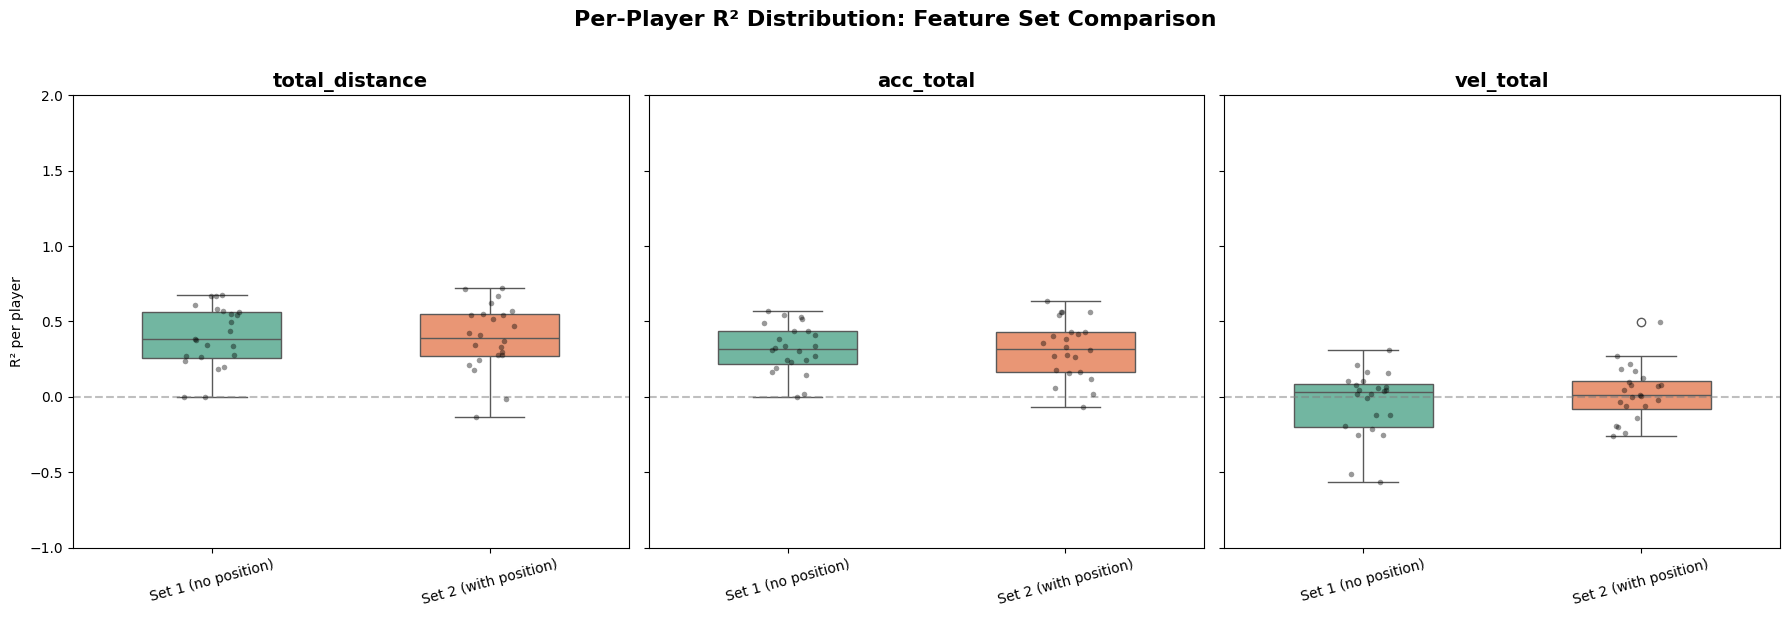

In [7]:
all_results = []
for set_name, df_r2 in results.items():
    tmp = df_r2.copy()
    tmp['feature_set'] = set_name
    all_results.append(tmp)

df_all = pd.concat(all_results, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for idx, t in enumerate(targets):
    ax = axes[idx]
    data = df_all[df_all['target'] == t]
    sns.boxplot(data=data, x='feature_set', y='R2', ax=ax, palette='Set2', width=0.5)
    sns.stripplot(data=data, x='feature_set', y='R2', ax=ax, color='black', alpha=0.4, size=4, jitter=True)
    ax.set_title(f'{t}', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('R² per player' if idx == 0 else '')
    ax.axhline(y=0, color='grey', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(-1, 2)

fig.suptitle('Per-Player R² Distribution: Feature Set Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()